In [ ]:
!pip install librosa numpy matplotlib soundfile openai-whisper

In [ ]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

Saving test.mp3 to test (1).mp3
Uploaded file: test (1).mp3


In [ ]:
import librosa
import numpy as np
import soundfile as sf

y, sr = librosa.load(filename, sr=16000)

# STFT
D = librosa.stft(y)
magnitude, phase = np.abs(D), np.angle(D)

# ---- MANUAL DSP IMPROVEMENTS ----

# 1) Use first 0.9s as noise sample
noise_frames = int(0.9 * sr / 512)
noise_mag = np.mean(magnitude[:, :noise_frames], axis=1, keepdims=True)

# 2) Over-subtraction factor (key DSP tuning parameter)
alpha = 1.8     # try 1.0 – 2.0

# 3) Spectral subtraction with flooring
subtracted = magnitude - alpha * noise_mag
clean_mag = np.maximum(subtracted, 0.02 * noise_mag)  # spectral flooring (beta = 0.005)

# ---------------------------------

# Reconstruct signal
clean_D = clean_mag * np.exp(1j * phase)
clean_audio = librosa.istft(clean_D)

sf.write("cleaned.wav", clean_audio, sr)
print("Manual DSP noise removal complete")


Manual DSP noise removal complete


In [ ]:
'''import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

# Load audio
y, sr = librosa.load(filename, sr=16000)
!pip install noisereduce

import noisereduce as nr

# assume first 0.5 sec is noise profile
noise_part = y[:int(sr*0.5)]

clean_audio = nr.reduce_noise(y=y, y_noise=noise_part, sr=sr)

sf.write("cleaned.wav", clean_audio, sr)
print("Noise reduction complete with noisereduce")



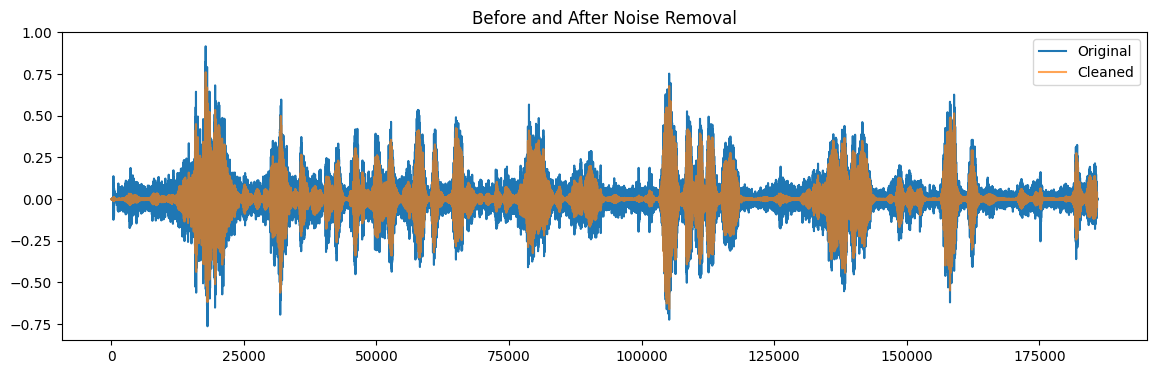

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(y, label="Original")
plt.plot(clean_audio, label="Cleaned", alpha=0.7)
plt.legend()
plt.title("Before and After Noise Removal")
plt.show()


In [ ]:
import whisper

model = whisper.load_model("tiny")
result = model.transcribe("cleaned.wav")

print("\nTRANSCRIPTION OF CLEANED AUDIO:")
print(result["text"])


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



TRANSCRIPTION OF CLEANED AUDIO:
 Hello, I am speaking to the President of United States. Hello, hello. How is the weather there? It's rainy today. Awesome.


In [ ]:
from IPython.display import Audio
Audio("cleaned.wav")